# Name
Please write your name down here:

Peter Brederlow

**Random forests on mouse phenotype data**

Today we will use one of the most popular supervised learning methods: random forests. It is an ensemble method, which means it uses multiple predictors and makes its final prediction based on a democratic vote of its individual predictors.

These sub-predictors are called decision trees, hence the name forest. Decision trees are labelled binary trees. Every leaf is associated with a class label, and every branching point is a test for a feature value against a threshold: if the feature value is smaller than the threshold, the sample is passed on towards the left branch, otherwise it continues on the right branch. The prediction is the label of the leaf it eventually reaches, starting from the tree's root.

Random forests generate a set of decision trees in a structured (but somewhat random) manner, and aggregate their results.

We will load the data as usual:

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import roc_curve, recall_score, matthews_corrcoef, classification_report, auc
from sklearn.model_selection import learning_curve
from dtreeviz.trees import model
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from IPython.display import display, HTML

# Data Loading & Preprocessing

In [59]:
phenotype = pd.read_excel(
    'https://raw.githubusercontent.com/Practical-Integrative-Bioinformatics/00_Introduction/main/data/phenotype.xlsx', 
    sheet_name=None, 
    na_values='x', 
    index_col='@format=column'
)

# The VO2Max table doesn't follow their own column naming conventions, so fix that first
def rename_vo2_cols(colname):
    return colname.replace('CD', 'CD_').replace('HFD', 'HFD_').replace('__', '_')

phenotype['VO2Max'].rename(columns=rename_vo2_cols, inplace=True)

def split_cd_hfd(input_df):
    input_df.index.name = 'strain'  # change that weird @format=column Excel index label to something meaningful
    input_cd = input_df.filter(regex=r'_CD|CD_') # loc[:, (input_df.columns.str.contains('CD_')) | (input_df.columns.str.contains('_CD'))]
    input_hfd = input_df.filter(regex=r'_HFD|HFD_') #loc[:, (input_df.columns.str.contains('HFD_')) | (input_df.columns.str.contains('_HFD'))]

    input_cd.columns = input_cd.columns.str.replace(r'_CD|CD_', '', regex=True)
    input_hfd.columns = input_hfd.columns.str.replace(r'_HFD|HFD_', '', regex=True)
    
    input_cd.insert(0, 'diet', 'CD')
    input_hfd.insert(0, 'diet', 'HFD')
    
    kept_columns = input_cd.columns.intersection(input_hfd.columns)
    
    df_both = pd.concat([input_cd, input_hfd], sort=False)[kept_columns]
    df_both.columns.name = 'experiment'  # added only later
    
    return df_both.reset_index().set_index(['strain', 'diet']).sort_index()

pheno = pd.concat([split_cd_hfd(sheet) for sheet_name, sheet in phenotype.items() if sheet_name != "NEW"], axis=1)

# let's remove the main offenders for missing values, both samples and features
pheno = pheno.loc[pheno.T.isna().sum() < 42]  # samples with lots of missing features
pheno = pheno.loc[:, pheno.isna().sum() < 11]  # features with still too many missing values

# a peek at what missing data we are left with:
# sns.clustermap(pheno.isna(), figsize=(10,10))

# Remove too informative columns for the sake of a more challenging classification task
banned = ["KNOWN_BATCH_EFFECT_BY_COHORT_ORDER", "BWGain", "Mass", "BodyWeight", "Food", "Sacrifice"]
kept_cols = [x for x in pheno.columns if all(b not in x for b in banned)]

data_raw = pheno.loc[:, kept_cols]

/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unkno

Imputing missing values:

In [60]:
imputer = SimpleImputer(strategy='median')
data = pd.DataFrame(imputer.fit_transform(data_raw), index=data_raw.index, columns=data_raw.columns)

target = data.index.to_frame()['diet'].replace({'CD': 0, 'HFD': 1})

# Use and evaluate a random forest classifier

Create a `RandomForestClassifier` with 10 trees and otherwise default settings. Calculate its accuracy on `data` with `cross_val_score`. You can use whatever cross-validation class you prefer.

You hopefully found that the random forest was very accurate even though we skipped the data standardization step. This is in stark contrast with yesterday's SVMs which performed poorly on unnormalized data.

Random forests are one of the few machine learning algorithms that don't require or benefit from standardization, since decision trees look at individual features (and calculate split point values) independently, and therefore it doesn't matter if the features' scaling is different.

In [61]:
# YOUR CODE HERE
target = target.astype(int)
rf = RandomForestClassifier(random_state=69, n_estimators=10)
rf.fit(data, target)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
acc = cross_val_score(rf, data, target, cv=skf)
print(f"Mean CV accuracy: {np.mean(acc):.3f}")
print(f"Std CV accuracy: {np.std(acc):.3f}")

Mean CV accuracy: 0.944
Std CV accuracy: 0.057


## Re-run the previous cell a few times

Why does the accuracy figure jump around?

For me it does not, but this is because I have set a random state in the random forst model that makes it reproducible. If I change it, the accuracies change as well.  
The reason for this, that the bootstrapping, as well as the feature choice to build the trees is randomized. This gives differing trees everytime, which then lead to slightly differing accuracies in the ensemble voting.

In [62]:
# YOUR CODE HERE
target = target.astype(int)
rf = RandomForestClassifier( n_estimators=10)
rf.fit(data, target)
acc = cross_val_score(rf, data, target, cv=skf)
print(f"Mean CV accuracy: {np.mean(acc):.3f}")
print(f"Std CV accuracy: {np.std(acc):.3f}")

Mean CV accuracy: 0.955
Std CV accuracy: 0.015


## Get a more precise accuracy figure with repeated, shuffled cross-validation

Your model's accuracy is just an estimate. Even if you evaluate it on the exact same data, you may still get different values each time due to the inherent randomness of the model, or the cross-validation folds that you get (due to different number of folds, or shuffling).

The `RepeatedKFold` or `RepeatedStratifiedKFold` classes help you arrive at a more precise accuracy figure by doing many rounds of shuffled cross-validation, all you have to do is average the fold accuracies at the end.

You can use the good old `cross_val_score` method with the `cv=RepeatedStratifiedKFold(3, n_repeats=10)` keyword.

Note: repeated cross-validators only work with `cross_val_score` but not `cross_val_predict`, since the latter method insists on returning only a single prediction label for each sample.

In [63]:
# YOUR CODE HERE
target = target.astype(int)
rf = RandomForestClassifier(n_estimators=10)
rf.fit(data, target)
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=10, random_state=42)
acc = cross_val_score(rf, data, target, cv=rskf)
print(f"Mean CV accuracy: {np.mean(acc):.3f}")
print(f"Std CV accuracy: {np.std(acc):.3f}")

Mean CV accuracy: 0.910
Std CV accuracy: 0.060


## Determine the uncertainty of the accuracy

We now have a more accurate estimation for the mean of the model's accuracy, but this accuracy will not be achieved with every instance of the model. We should also try to determine the error bars around that accuracy value. Therefore we should take a closer look at the distribution of the accuracies from different instances of the model.

Use `cv=StratifiedKFold(3, shuffle=True)` this time, so that we have one accuracy value for each pass over the dataset. Run `cross_val_score` 100 times inside a `for` loop, save the 100 accuracy values that you get into a list, and plot the histogram of the resulting accuracy values. You do not have to use a for-loop, though. Getting the accuracies differently is fine, too.

**What is the 90% confidence interval of the model's accuracy? (What is a "confidence interval" to begin with?)**

The function `np.percentile` can help you calculate the confidence interval. Put the lower and upper bounds of the confidence interval on the histogram as two vertical lines with `plt.axvline(...)`.

Mean CV accuracy over 100 runs: 0.909
Std CV accuracy over 100 runs: 0.032
90% confidence interval for the mean CV accuracy: [0.955, 0.853]


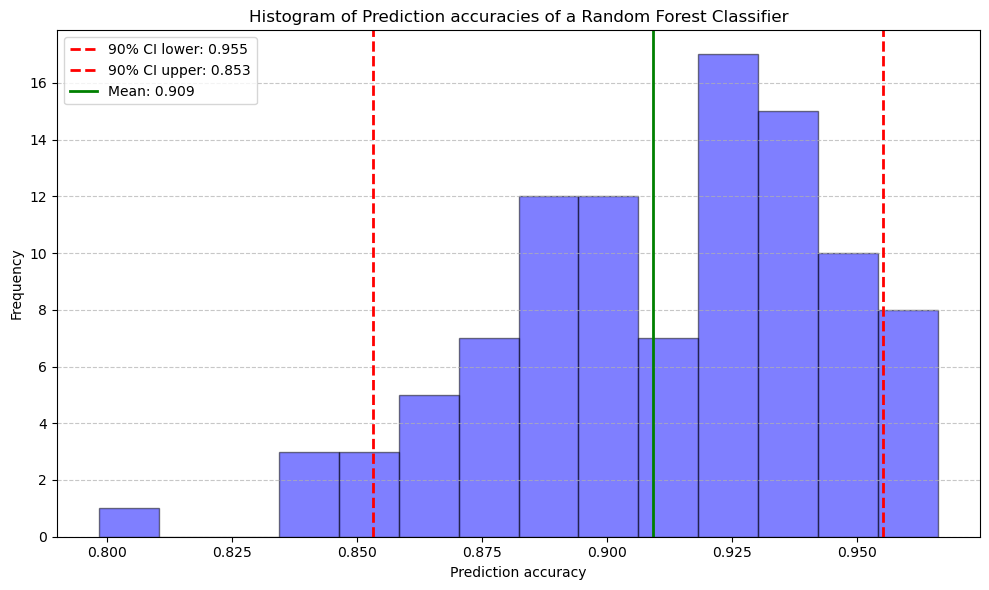

In [64]:
# YOUR CODE HERE
n = 100
cv = StratifiedKFold(n_splits=3, shuffle=True)
accuracies = []
for i in range(n):
    rf = RandomForestClassifier(n_estimators=10, random_state=i)
    acc = cross_val_score(rf, data, target, cv=cv)
    accuracies.append(np.mean(acc))
print(f"Mean CV accuracy over {n} runs: {np.mean(accuracies):.3f}")
print(f"Std CV accuracy over {n} runs: {np.std(accuracies):.3f}")
accuracies = pd.Series(accuracies)

#confidence interval
ci_upper = np.percentile(accuracies, 5)
ci_lower = np.percentile(accuracies, 95)
print(f"90% confidence interval for the mean CV accuracy: [{ci_lower:.3f}, {ci_upper:.3f}]")


min_value = accuracies.min()
max_value = accuracies.max()
bins = np.linspace(min_value, max_value, 15)  
plt.figure(figsize=(10, 6))
plt.hist(accuracies, bins=bins, color='blue', alpha=0.5, edgecolor='black')
plt.axvline(ci_lower, color='red', linestyle='--', linewidth=2, label=f'90% CI lower: {ci_lower:.3f}')
plt.axvline(ci_upper, color='red', linestyle='--', linewidth=2, label=f'90% CI upper: {ci_upper:.3f}')
plt.axvline(np.mean(accuracies), color='green', linestyle='-', linewidth=2, label=f'Mean: {np.mean(accuracies):.3f}')
plt.xlabel('Prediction accuracy')
plt.ylabel('Frequency')
plt.title('Histogram of Prediction accuracies of a Random Forest Classifier')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

As expected, the mean of the prediciton accuracy is approximately normally distributed with a slight skew to bigger accuracy values, and the 90% confidence intervals of the random forest are between 0.85 and 0.95, centered around roughly 0.9, so 90% accuracy. 

## Plot a single random forest's internal prediction probability values

`RandomForestClassifier`s have a `predict_proba` method by default, similar to `SVC`s with `proability=True` turned on. Use the convencience function `cross_val_predict` to get class membership probability estimates for each sample. Create a histogram of the probability values for HFD (second column).

**Use 100 bins for the histogram. Why are the probability values so rough? What are they derived from?**

Optional: Mark CD and HFD samples on the histogram with different colors. `plt.hist` can accept multiple arrays of values to plot, and present them on the same histogram with the `histtype='barstacked'` setting. For this, you first have to slice the probability values into two pieces based on `target` values.

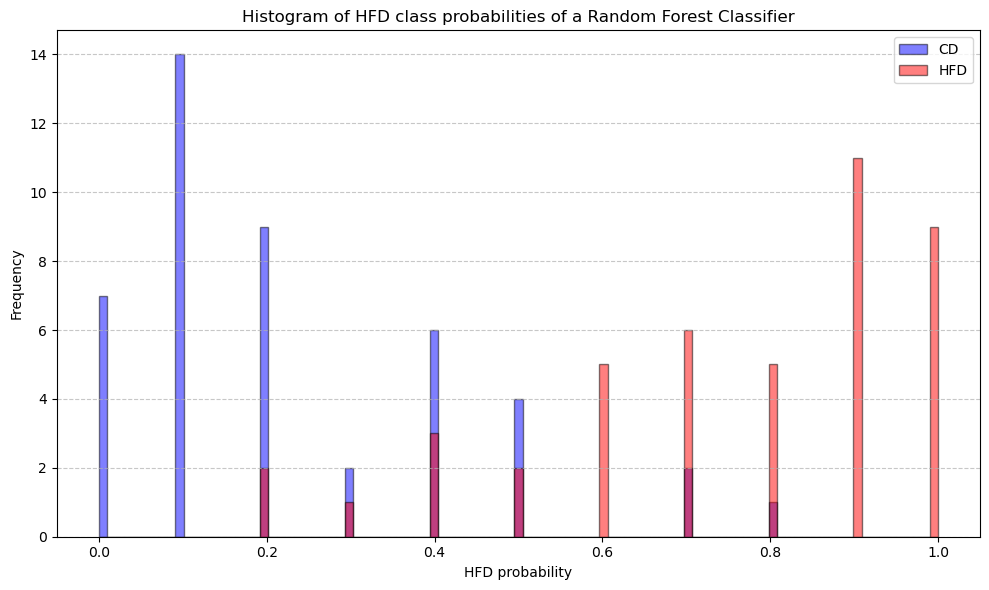

In [65]:
# YOUR CODE HERE
rf = RandomForestClassifier(n_estimators=10)
rf.fit(data, target)
pred_proba = cross_val_predict(rf, data, target, cv=skf, method='predict_proba')[:, 1] 

min_value = pred_proba.min()
max_value = pred_proba.max()
bins = np.linspace(min_value, max_value, 100)  
plt.figure(figsize=(10, 6))
plt.hist(pred_proba[target == 0], bins=bins, color='blue', alpha=0.5, edgecolor='black', label='CD', histtype='barstacked')
plt.hist(pred_proba[target == 1], bins=bins, color='red', alpha=0.5, edgecolor='black', label='HFD', histtype='barstacked')
plt.xlabel('HFD probability')
plt.ylabel('Frequency')
plt.title('Histogram of HFD class probabilities of a Random Forest Classifier')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Interestingly, even the random forest with 10 samples already leads to a limited amount of probabilities, that do not cluster the data perfectly. The limited choice then leads to only 8 actual bins in this case, although 100 were specified. These are essentially the only prediction probabilities that exist.  
As one can see, more complex trees shift the probabilities even further to probabilities closer to 0 or 1 respectively, leading to even more confidence in the prediction. Contrasting to that, the random forest gets worse, and offers even less bins, if one only use ntrees = 3.

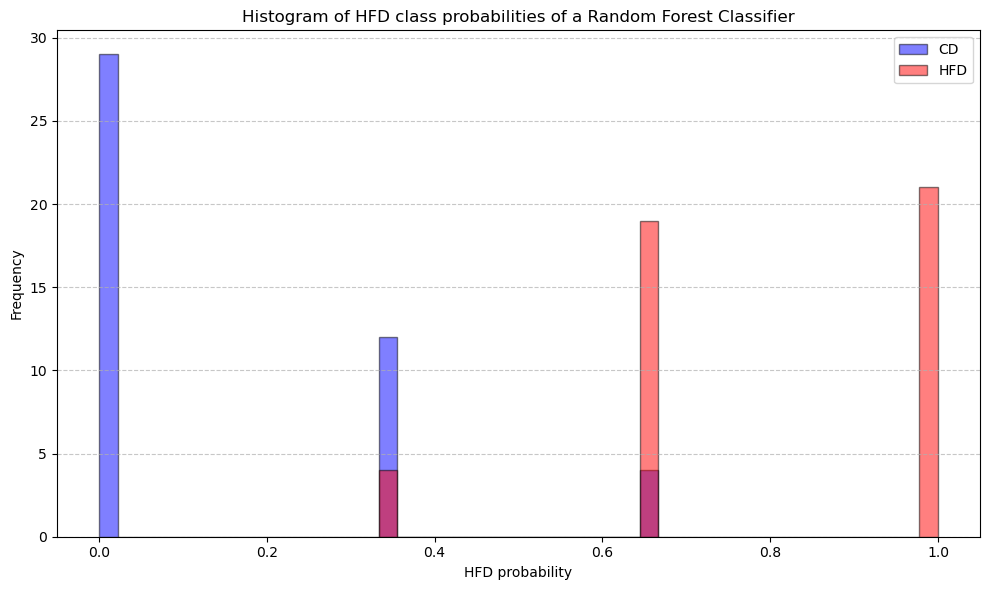

In [66]:
# YOUR CODE HERE
rf = RandomForestClassifier(n_estimators=3)
rf.fit(data, target)
pred_proba = cross_val_predict(rf, data, target, cv=skf, method='predict_proba')[:, 1] 

min_value = pred_proba.min()
max_value = pred_proba.max()
bins = np.linspace(min_value, max_value, 100)  
plt.figure(figsize=(10, 6))
plt.hist(pred_proba[target == 0], bins=30, color='blue', alpha=0.5, edgecolor='black', label='CD', histtype='barstacked')
plt.hist(pred_proba[target == 1], bins=30, color='red', alpha=0.5, edgecolor='black', label='HFD', histtype='barstacked')
plt.xlabel('HFD probability')
plt.ylabel('Frequency')
plt.title('Histogram of HFD class probabilities of a Random Forest Classifier')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

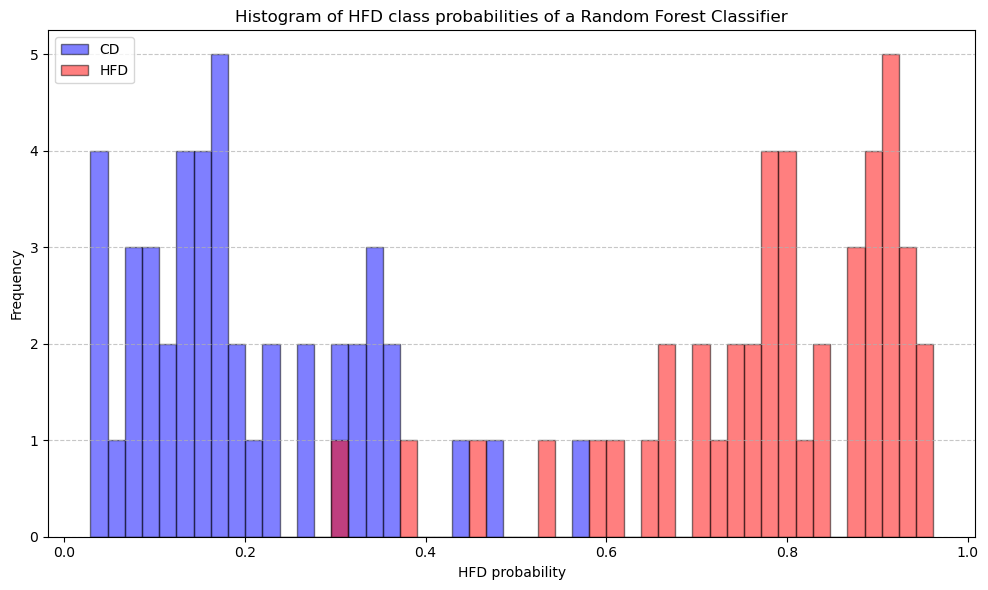

In [79]:
rf = RandomForestClassifier(n_estimators=1000, random_state=500)
rf.fit(data, target)
pred_proba = cross_val_predict(rf, data, target, cv=skf, method='predict_proba')[:, 1] 

min_value = pred_proba.min()
max_value = pred_proba.max()
bins = np.linspace(min_value, max_value, 50)  
plt.figure(figsize=(10, 6))
plt.hist(pred_proba[target == 0], bins=bins, color='blue', alpha=0.5, edgecolor='black', label='CD', histtype='barstacked')
plt.hist(pred_proba[target == 1], bins=bins, color='red', alpha=0.5, edgecolor='black', label='HFD', histtype='barstacked')
plt.xlabel('HFD probability')
plt.ylabel('Frequency')
plt.title('Histogram of HFD class probabilities of a Random Forest Classifier')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualize a decision tree

We have installed the decision tree visualization package `dtreeviz`. All you have to do is
 * fit a random forest (you can do it with the entire dataset)
 * find where it stores its individual decision trees
 * pick any one of them, and pass it to dtreeviz

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


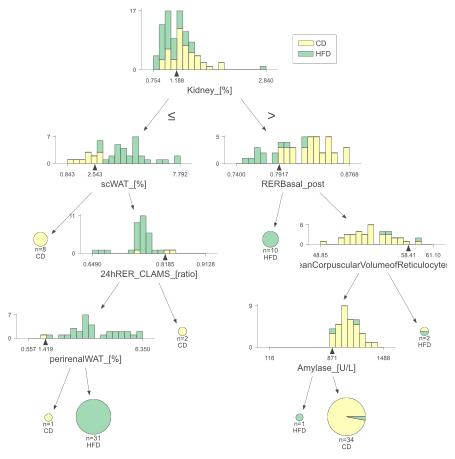

In [68]:
# YOUR CODE HERE
rf = RandomForestClassifier(n_estimators=30)
rf.fit(data, target)
tree = rf.estimators_[0]
viz_model = model(tree, 
                  X_train=data, 
                  y_train=target, 
                  feature_names=data.columns.tolist(), 
                  class_names=['CD', 'HFD'])
viz_model.view()

One can very clearly observe the splitting process for the individual trees, where based on the distributions on each variable, a separation point is found. Interestingly, this tree does not lead to a perfect accuracy be default. But one has to keep in mind, that this is just one of many differing decision trees in the random forest, so this tree is not necessarily a representative tree.

## Increase the number of trees and limit their depth

Make a random forest classifier with a 1000 trees. Limit their depth to 3.

Plot a label probability histogram like you did [before](#Plot-a-single-random-forest's-internal-prediction-probability-values). **Do the probability values look more continuous now?**

Visualize a few trees again. **Did anything change compared to last time?**

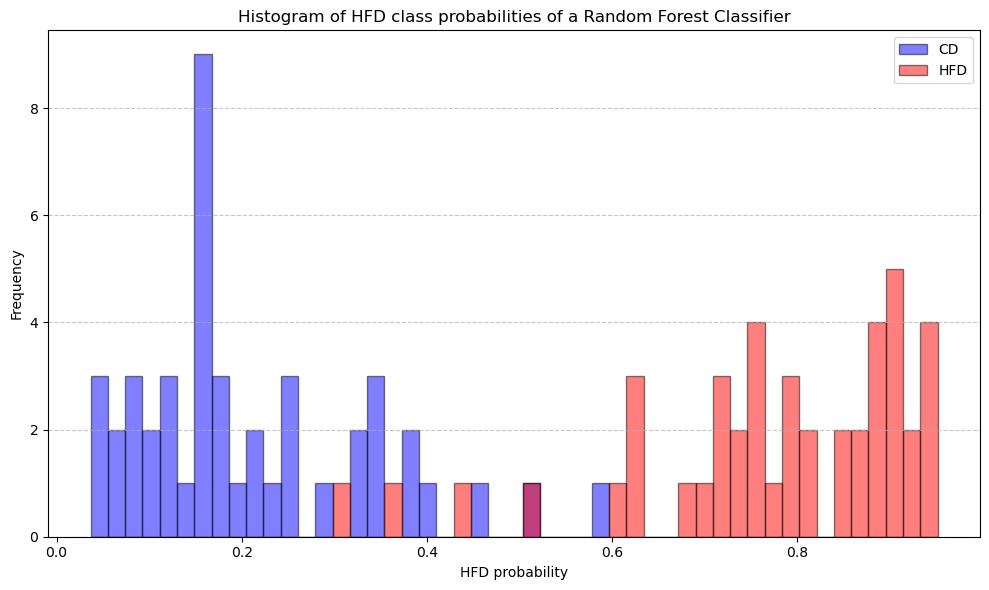

In [77]:
# YOUR CODE HERE
rf = RandomForestClassifier(n_estimators=1000, max_depth=3)
rf.fit(data, target)
pred_proba = cross_val_predict(rf, data, target, cv=skf, method='predict_proba')[:, 1] 

min_value = pred_proba.min()
max_value = pred_proba.max()
bins = np.linspace(min_value, max_value, 50)  
plt.figure(figsize=(10, 6))
plt.hist(pred_proba[target == 0], bins=bins, color='blue', alpha=0.5, edgecolor='black', label='CD', histtype='barstacked')
plt.hist(pred_proba[target == 1], bins=bins, color='red', alpha=0.5, edgecolor='black', label='HFD', histtype='barstacked')
plt.xlabel('HFD probability')
plt.ylabel('Frequency')
plt.title('Histogram of HFD class probabilities of a Random Forest Classifier')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


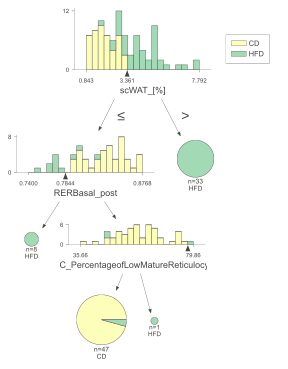

In [70]:
tree = rf.estimators_[0]
viz_model = model(tree, 
                  X_train=data, 
                  y_train=target, 
                  feature_names=data.columns.tolist(), 
                  class_names=['CD', 'HFD'])
viz_model.view()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


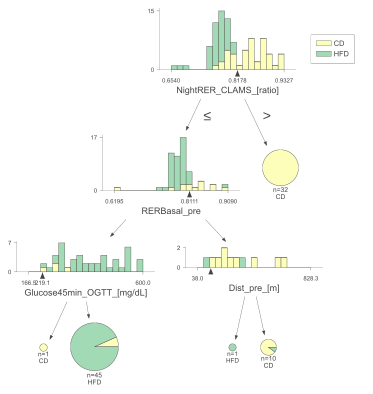

In [71]:
tree_4 = rf.estimators_[100]
viz_model = model(tree_4, 
                  X_train=data, 
                  y_train=target, 
                  feature_names=data.columns.tolist(), 
                  class_names=['CD', 'HFD'])
viz_model.view()

One can clearly see, that the prediction probabilities are more continuous (although per definition still discrete). However, it is visible, that with a lower depth, there are less extreme values, and a slightly broader distribution of the prediction values. And one also cannot observe any perfect predictions. Because of this, one also sees a few slightly more ambiguous genotypes, where the prediction probabilities are a bit closer to 0.5. This can be explained by the controlled low tree depth, that by default leads to some differing, unsophisticated trees that lower the ensemble probability.  
Futhermore, one can also see that the individual trees are decorrelated, and use differing features to separate the data, which are always limited to three. But that they also use informative features such as VO2-max, which are a bit more conserved. One has to note, that these features will get excluded in some trees because of the decorrelation, parameterized by the max depth of the tree. 

# Create a ROC curve
Now that you know how to access the continuous internal prediction variables (class membership probability in this case) you can create a ROC plot easily.

Optional: Generate a bunch of ROC curve values and plot their "average".

/var/folders/vm/8qbbn1f91lb9f4yl4gd82lch0000gn/T/ipykernel_34488/3917246549.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.


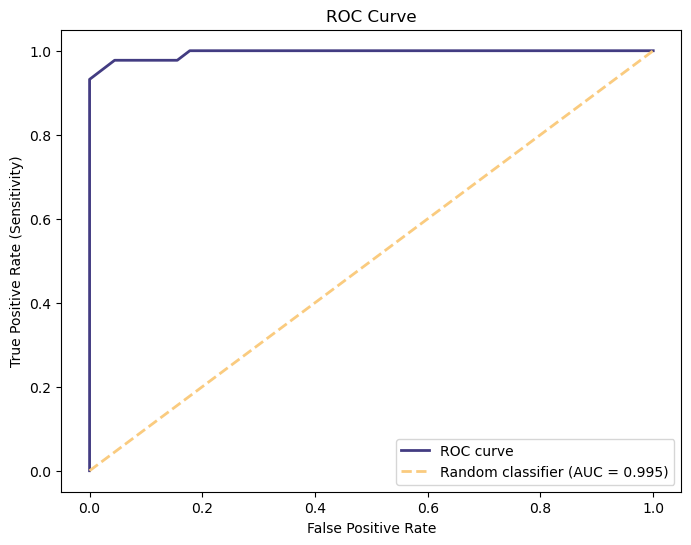

In [76]:
# YOUR CODE HERE
decision_scores = cross_val_predict(rf, data, target, cv=skf, method='predict_proba')[:, 1]
fpr, tpr, thresholds = roc_curve(target, decision_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve', color = '#433c82', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label=f'Random classifier (AUC = {roc_auc:.3f})', linewidth=2, color = '#facb7f')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Feature importances

Random forests utilize their internal structure not just to provide probability estimates, but also to estimate the importance of different features. Therefore random forests are popular not just for prediction models but also for general data exploration.

**How do you think feature importances are derived?**

Find a way to access the feature importance values, turn it into a Series with the feature names as the index (found in `data.columns`), and sort them from best to last. **Are the winners familiar from yesterday?**

Top 20 most important features:
experiment
RERBasal_post                       0.078340
scWAT_[%]                           0.073875
NightRER_CLAMS_[ratio]              0.071088
24hRER_CLAMS_[ratio]                0.058479
scWAT_[g]                           0.051613
RERBasal_pre                        0.044950
perirenalWAT_[%]                    0.038923
VO2Max_pre                          0.037267
Cholesterol_[mmol/L]                0.031671
RDW.RedCellDistributionWidth_[%]    0.028266
perirenalWAT_[g]                    0.026311
24hZTot_TSE_[#/hr]                  0.023227
Gastrocnemius_[%]                   0.022968
NightZTot_TSE_[#/hr]                0.022939
Heart_[%]                           0.022454
DayRER_CLAMS_[ratio]                0.019946
LDL_[mmol/L]                        0.019940
DayZTot_TSE_[#/hr]                  0.012537
InsulinAUC_OGTT_[AUC]               0.012419
Glucose120min_OGTT_[mg/dL]          0.012135
dtype: float64


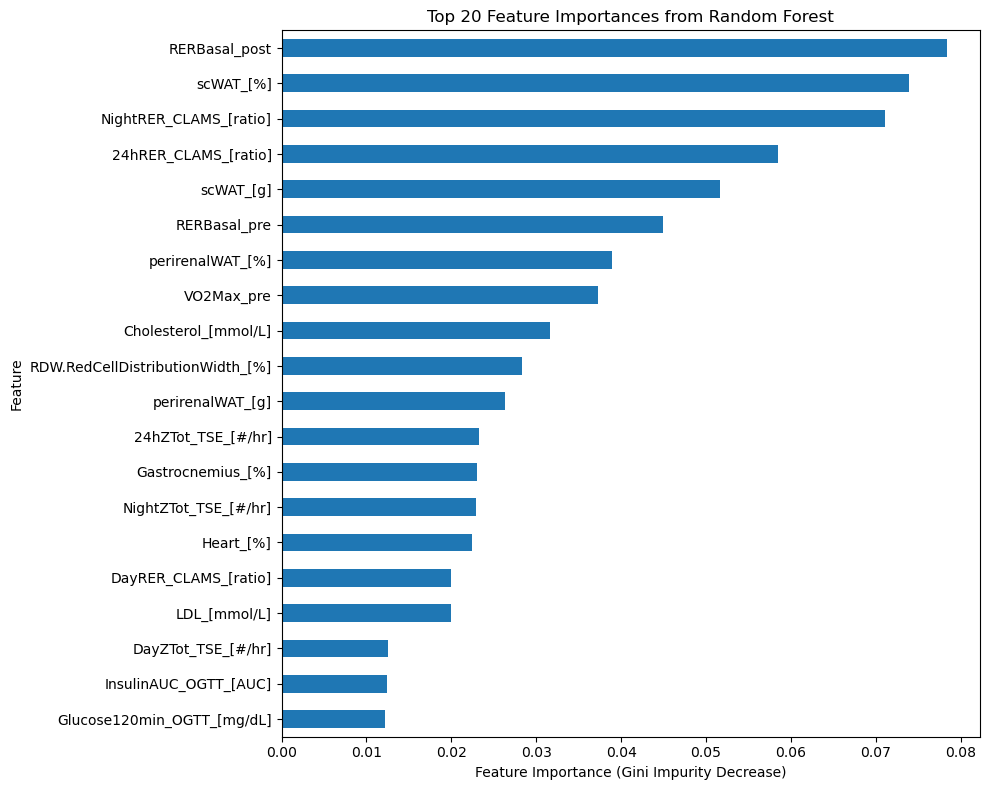

In [73]:
# YOUR CODE HERE
feature_importances = pd.Series(rf.feature_importances_, index=data.columns)
feature_importances_sorted = feature_importances.sort_values(ascending=False)

# top 20
print("Top 20 most important features:")
print(feature_importances_sorted.head(20))
plt.figure(figsize=(10, 8))
feature_importances_sorted.head(20).plot(kind='barh')
plt.xlabel('Feature Importance (Gini Impurity Decrease)')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances from Random Forest')
plt.gca().invert_yaxis()  # Most important at top
plt.tight_layout()
plt.show()

Similar to the relevant features for the support vector machine, the most important features are related to respiratory exchange rate, as well as other cardiovascular parameters such as Red Blood Cell distribution. Furthermore, subcutaneous white adipose tissue mass and volume are other predictive predictors. A change in the amount of adipose tissues is also very well explainable based on an 'unhealthy' high fat diet.

# Optional: Play around

Ideas:

* Random Forests use a lot of randomization for the generation of each decision tree. You have some control over  this with parameters like `max_features` and `max_samples`. Look at these (or other) parameters and try to improve the accuracy of an RFC by trying out different combinations.
* Feature selection: Look for correlations in the features, search for clusters among them and choose one representative feature per cluster. Try to achieve high accuracy with just a few features.
* Eliminate obvious features and test how the model performs without them. Add (or since we use linear, un-normalized features: multiply) noise to the data.

    max_features  max_samples  mean_accuracy  std_accuracy
0              1          0.5       0.877011      0.040552
1              1          0.7       0.887739      0.014967
2              1          1.0       0.898851      0.001626
3              3          0.5       0.899234      0.046608
4              3          0.7       0.921839      0.041166
5              3          1.0       0.910345      0.056365
6              5          0.5       0.932950      0.026749
7              5          0.7       0.966667      0.027217
8              5          1.0       0.944444      0.056656
9             10          0.5       0.955556      0.031427
10            10          0.7       0.966667      0.027217
11            10          1.0       0.944444      0.041574
12            20          0.5       0.933333      0.054433
13            20          0.7       0.955556      0.041574
14            20          1.0       0.955556      0.041574
15            50          0.5       0.955556      0.0415

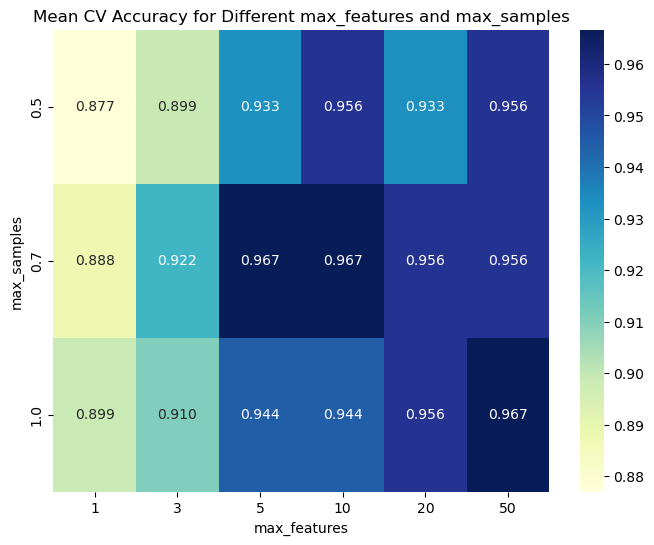

In [74]:
# YOUR CODE HERE
max_feature_grid = [1, 3, 5, 10, 20, 50]
max_samples_grid = [0.5, 0.7, 1.0]
results = []
for max_features in max_feature_grid:
    for max_samples in max_samples_grid:
        rf = RandomForestClassifier(n_estimators=100, max_features=max_features, max_samples=max_samples, random_state=42)
        acc = cross_val_score(rf, data, target, cv=skf)
        results.append({
            'max_features': max_features,
            'max_samples': max_samples,
            'mean_accuracy': np.mean(acc),
            'std_accuracy': np.std(acc)
        })
results_df = pd.DataFrame(results)
print(results_df)
pivot_table = results_df.pivot(index='max_samples', columns='max_features', values='mean_accuracy')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title('Mean CV Accuracy for Different max_features and max_samples')
plt.xlabel('max_features')  
plt.ylabel('max_samples')
plt.show()


The best combination of max features is either at 0.7 and then the ideal amount of maximal features for a tree is either at 5 or 10, or a combination of 50 featrues and all samples of the training set. Since 70% of the training set and 5 features is the most parsimonious model, and probably also the most generalizable, this combination is probably the ideal way of choosing the parameters. 